# Clasificacion Binaria: Prediccion del Ganador Electoral

## Objetivo
Predecir si un candidato **gana o no gana** la eleccion a partir de sus interacciones en redes sociales.

## Mejoras respecto al modelo de regresion
1. **Clasificacion binaria** en lugar de regresion (mas factible con pocos datos).
2. **Dominancia relativa**: % de interacciones del candidato vs total de candidatos trazados en su ciudad.
3. **Metrica clave**: accuracy a nivel ciudad (en cuantas ciudades se identifica al ganador).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             classification_report, confusion_matrix, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import spearmanr

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 5)
SEED = 42
np.random.seed(SEED)
print('Librerias cargadas')


C:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Librerias cargadas


## 1. Carga de Datos y Preparacion

In [2]:
# Cargar panel y resultados electorales
panel = pd.read_csv('panel_historico_reconstruido.csv')
elec = pd.read_excel('../Colombia/Resultados electorales.xlsx')

# Excluir Piedecuesta y Bogota
EXCLUIR = ['Piedecuesta', 'Bogot\u00e1 D.C.']
elec = elec[~elec['Municipio'].isin(EXCLUIR)].copy()

# IDs con publicaciones activas
panel_ids = set(panel['id_candidato'].unique())
df_target = elec[elec['ID Candidato'].isin(panel_ids)].copy()

# Target binario
df_target['y'] = (df_target['Ganador'].str.strip().str.lower() == 's\u00ed').astype(int)

print(f'Candidatos trazados: {len(df_target)} en {df_target["Municipio"].nunique()} ciudades')
print(f'Ganadores: {df_target["y"].sum()} | No ganadores: {(1 - df_target["y"]).sum()}')
print(f'Balance: {df_target["y"].mean()*100:.1f}% positivos')


Candidatos trazados: 112 en 31 ciudades
Ganadores: 27 | No ganadores: 85
Balance: 24.1% positivos


## 2. Feature Engineering

### Features nuevos clave:
- **Dominancia relativa**: % de interacciones del candidato sobre el total de su ciudad.
- **Frecuencia de publicacion**: posts por dia en el periodo.
- **Diversidad de plataformas**: numero de redes activas.

In [3]:
interaction_types = ['likes', 'comentarios', 'compartidos', 'vistas', 'favoritos',
                     'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']

# --- Agregar interacciones por candidato ---
features_list = []
for cand_id in df_target['ID Candidato'].unique():
    posts = panel[panel['id_candidato'] == cand_id]
    row = {'id_candidato': cand_id}
    
    # Basicos
    row['n_posts'] = len(posts)
    plats = posts['platform'].unique()
    row['n_redes'] = len(plats)
    row['tiene_facebook'] = int('Facebook' in plats)
    row['tiene_tiktok'] = int('TikTok' in plats)
    row['tiene_twitter'] = int('Twitter' in plats)
    
    # Dias activos
    if len(posts) > 0:
        fechas = pd.to_datetime(posts['fecha'], errors='coerce').dropna()
        if len(fechas) > 0:
            row['dias_activos'] = (fechas.max() - fechas.min()).days + 1
            row['posts_por_dia'] = len(posts) / max(row['dias_activos'], 1)
        else:
            row['dias_activos'] = 0
            row['posts_por_dia'] = 0
    else:
        row['dias_activos'] = 0
        row['posts_por_dia'] = 0
    
    # Totales por tipo de interaccion
    for itype in interaction_types:
        col_d14 = f'{itype}_acum_d14'
        col_d3 = f'{itype}_acum_d3'
        if col_d14 in posts.columns:
            total = posts[col_d14].sum()
            row[f'total_{itype}'] = total
            row[f'avg_{itype}'] = posts[col_d14].mean() if len(posts) > 0 else 0
            row[f'max_{itype}'] = posts[col_d14].max() if len(posts) > 0 else 0
            # Crecimiento tardio
            d3 = posts[col_d3].sum() if col_d3 in posts.columns else 0
            row[f'late_growth_{itype}'] = (total - d3)
    
    # Interacciones totales (likes + comentarios + compartidos)
    row['total_engagement'] = row.get('total_likes', 0) + row.get('total_comentarios', 0) + row.get('total_compartidos', 0)
    row['avg_engagement'] = row['total_engagement'] / max(row['n_posts'], 1)
    
    features_list.append(row)

df_feat = pd.DataFrame(features_list).fillna(0)

# --- Merge con target ---
df = df_target[['ID Candidato', 'Municipio', 'Candidato', 'Votos', 'y']].merge(
    df_feat, left_on='ID Candidato', right_on='id_candidato', how='inner'
).drop(columns=['id_candidato'])

# --- DOMINANCIA RELATIVA (feature clave) ---
# % de engagement de este candidato vs total de candidatos trazados en su ciudad
city_totals = df.groupby('Municipio')['total_engagement'].transform('sum')
df['dominancia_engagement'] = df['total_engagement'] / city_totals.clip(lower=1) * 100

# Dominancia por tipo
for itype in ['likes', 'comentarios', 'compartidos', 'vistas']:
    col = f'total_{itype}'
    if col in df.columns:
        city_sum = df.groupby('Municipio')[col].transform('sum')
        df[f'dominancia_{itype}'] = df[col] / city_sum.clip(lower=1) * 100

# Candidatos por ciudad
df['n_candidatos_ciudad'] = df.groupby('Municipio')['ID Candidato'].transform('count')

print(f'Dataset: {len(df)} candidatos x {df.shape[1]} columnas')
print(f'\nFeatures de dominancia (ejemplo):')
print(df[['Candidato', 'Municipio', 'dominancia_engagement', 'y']].sort_values('dominancia_engagement', ascending=False).head(10).to_string(index=False))


Dataset: 112 candidatos x 64 columnas

Features de dominancia (ejemplo):
                        Candidato    Municipio  dominancia_engagement  y
           Alejandro Char Chaljub Barranquilla              97.581028  1
    Raul Eduardo Cardona Gonzalez     Envigado              94.281630  1
        Nicolas Martin Toro Muñoz        Pasto              91.803123  1
                  Mikhail Krasnov        Tunja              87.215755  1
     Rosa Maria Acevedo Jaramillo       Itagüí              81.327201  0
Ligia del Carmen Cordoba Martinez Buenaventura              77.483938  1
      Jorge Eduardo Rojas Giraldo    Manizales              71.392698  1
          Mauricio Salazar Pelaez      Pereira              70.294670  1
    Natalia Eugenia Lopez Fuentes     Montería              69.337898  0
     Alvaro Alejandro Eder Garces         Cali              67.817043  1


## 3. Seleccion de Features

In [4]:
exclude = ['ID Candidato', 'Municipio', 'Candidato', 'Votos', 'y']
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols].values.astype(np.float64)
y = df['y'].values

# Correlacion con target
corrs = []
for i, col in enumerate(feature_cols):
    corr, pval = spearmanr(X[:, i], y)
    corrs.append({'feature': col, 'corr': corr, 'abs_corr': abs(corr), 'pval': pval})
df_corr = pd.DataFrame(corrs).sort_values('abs_corr', ascending=False)

print('=== TOP 15 FEATURES MAS CORRELACIONADOS CON GANAR ===')
print(df_corr.head(15)[['feature', 'corr', 'pval']].to_string(index=False))

# Seleccionar top features
TOP_K = 15
selected = df_corr.head(TOP_K)['feature'].tolist()
print(f'\nFeatures seleccionados: {selected}')

feat_idx = [feature_cols.index(f) for f in selected]
X_sel = X[:, feat_idx]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)
print(f'\nX final: {X_scaled.shape}')


=== TOP 15 FEATURES MAS CORRELACIONADOS CON GANAR ===


               feature      corr         pval
      dominancia_likes  0.469067 1.822523e-07
 dominancia_engagement  0.461964 2.941019e-07
dominancia_comentarios  0.425811 2.860333e-06
dominancia_compartidos  0.412250 6.289119e-06
     dominancia_vistas  0.369639 6.045632e-05
   n_candidatos_ciudad -0.261438 5.363356e-03
           total_likes  0.256647 6.303918e-03
             avg_likes  0.250191 7.802043e-03
      total_engagement  0.250190 7.802179e-03
     total_comentarios  0.245674 9.029155e-03
       avg_comentarios  0.244381 9.410370e-03
        avg_engagement  0.242442 1.000865e-02
            avg_vistas  0.241799 1.021448e-02
     late_growth_likes  0.231163 1.419591e-02
   late_growth_fb_care  0.229794 1.479558e-02

Features seleccionados: ['dominancia_likes', 'dominancia_engagement', 'dominancia_comentarios', 'dominancia_compartidos', 'dominancia_vistas', 'n_candidatos_ciudad', 'total_likes', 'avg_likes', 'total_engagement', 'total_comentarios', 'avg_comentarios', 'avg_enga

## 4. Comparacion de Modelos (Leave-One-Out CV)

In [5]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=2000, random_state=SEED),
    'SVM (RBF)': SVC(C=10, kernel='rbf', probability=True, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=4, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, 
                                                     learning_rate=0.05, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000, 
                          learning_rate='adaptive', random_state=SEED,
                          early_stopping=True, validation_fraction=0.15),
}

loo = LeaveOneOut()
results = {}

print('Evaluando con Leave-One-Out CV...\n')

for name, model in models.items():
    y_pred = cross_val_predict(model, X_scaled, y, cv=loo)
    y_proba = cross_val_predict(model, X_scaled, y, cv=loo, method='predict_proba')[:, 1]
    
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)
    
    results[name] = {'Accuracy': acc, 'F1': f1, 'AUC': auc, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'{name:25s} | Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}')

print('\nEvaluacion completada')


Evaluando con Leave-One-Out CV...



Logistic Regression       | Acc=0.812  F1=0.488  AUC=0.770


SVM (RBF)                 | Acc=0.714  F1=0.238  AUC=0.502


Random Forest             | Acc=0.741  F1=0.326  AUC=0.709


Gradient Boosting         | Acc=0.705  F1=0.327  AUC=0.657


MLP                       | Acc=0.598  F1=0.483  AUC=0.731

Evaluacion completada


## 5. Accuracy a Nivel Ciudad

La metrica mas importante: **en cuantas ciudades el candidato con mayor probabilidad predicha es efectivamente el ganador?**

In [6]:
def city_accuracy(df, y_proba, model_name):
    df_eval = df[['Municipio', 'Candidato', 'y']].copy()
    df_eval['proba'] = y_proba
    
    aciertos = 0
    total_ciudades = 0
    detalles = []
    
    for ciudad, group in df_eval.groupby('Municipio'):
        # Ganador real
        real_winner = group[group['y'] == 1]
        if len(real_winner) == 0:
            continue
        
        total_ciudades += 1
        # Candidato con mayor probabilidad predicha
        pred_winner = group.loc[group['proba'].idxmax()]
        
        acerto = pred_winner['y'] == 1
        if acerto:
            aciertos += 1
        
        detalles.append({
            'Ciudad': ciudad,
            'Ganador real': real_winner.iloc[0]['Candidato'],
            'Prediccion': pred_winner['Candidato'],
            'Prob predicha': pred_winner['proba'],
            'Acierto': acerto
        })
    
    return aciertos, total_ciudades, pd.DataFrame(detalles)

print('=== ACCURACY POR CIUDAD ===\n')
city_results = {}

for name, res in results.items():
    aciertos, total, detalles = city_accuracy(df, res['y_proba'], name)
    city_results[name] = {'aciertos': aciertos, 'total': total, 
                           'pct': aciertos/total*100, 'detalles': detalles}
    print(f'{name:25s} | {aciertos}/{total} ciudades correctas ({aciertos/total*100:.1f}%)')

# Mejor modelo
best = max(city_results, key=lambda x: city_results[x]['pct'])
print(f'\nMejor modelo: {best} ({city_results[best]["aciertos"]}/{city_results[best]["total"]} ciudades)')


=== ACCURACY POR CIUDAD ===

Logistic Regression       | 16/27 ciudades correctas (59.3%)
SVM (RBF)                 | 11/27 ciudades correctas (40.7%)
Random Forest             | 14/27 ciudades correctas (51.9%)
Gradient Boosting         | 11/27 ciudades correctas (40.7%)


MLP                       | 14/27 ciudades correctas (51.9%)

Mejor modelo: Logistic Regression (16/27 ciudades)


## 6. Detalle del Mejor Modelo

=== PREDICCIONES POR CIUDAD: Logistic Regression ===

         Ciudad                      Ganador real                        Prediccion  Prob predicha  Acierto
       Apartadó  Hector Rangel Palacios Rodriguez       Adolfo David Romero Benitez       0.515194    False
         Itagüí         Diego Leon Torres Sanchez      Rosa Maria Acevedo Jaramillo       0.777371    False
   Dosquebradas           Roberto Jimenez Naranjo         Tatiana Lopez Saldarriaga       0.494321    False
       Montería    Hugo Fernando Kerguelen Garcia     Natalia Eugenia Lopez Fuentes       0.884016    False
           Cali      Alvaro Alejandro Eder Garces            Deninson Mendoza Ramos       0.256211    False
      Cartagena             Dumek Jose Turbay Paz             Javier Julio Bejarano       0.230481    False
          Bello    Yulieth Lorena Gonzalez Ospina     Nestor David Restrepo Bonnett       0.331491    False
        Soledad      Alcira Paola Sandoval Ibañez          Jose Joao Herrera Iranz

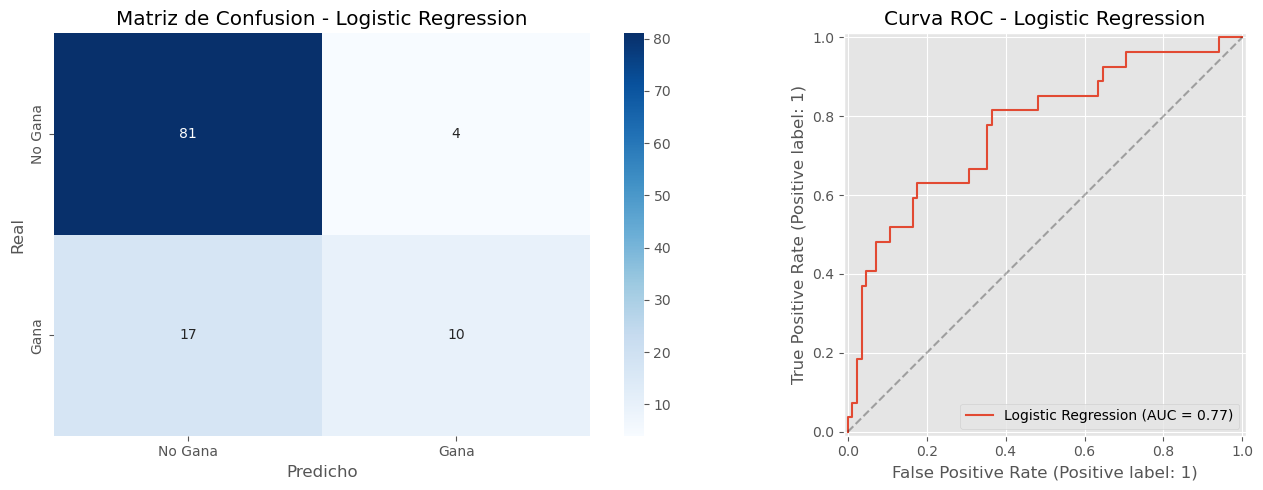


              precision    recall  f1-score   support

     No Gana       0.83      0.95      0.89        85
        Gana       0.71      0.37      0.49        27

    accuracy                           0.81       112
   macro avg       0.77      0.66      0.69       112
weighted avg       0.80      0.81      0.79       112



In [7]:
best_name = best
best_res = results[best_name]
best_city = city_results[best_name]

# Tabla de predicciones por ciudad
print(f'=== PREDICCIONES POR CIUDAD: {best_name} ===\n')
det = best_city['detalles'].sort_values('Acierto')
print(det.to_string(index=False))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, best_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Gana', 'Gana'], yticklabels=['No Gana', 'Gana'])
axes[0].set_title(f'Matriz de Confusion - {best_name}')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# ROC curve
RocCurveDisplay.from_predictions(y, best_res['y_proba'], ax=axes[1], name=best_name)
axes[1].set_title(f'Curva ROC - {best_name}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)

plt.tight_layout()
plt.show()

# Classification report
print(f'\n{classification_report(y, best_res["y_pred"], target_names=["No Gana", "Gana"])}')


## 7. Comparacion Visual

=== TABLA COMPARATIVA FINAL ===
                     Accuracy (candidato)  F1 Score  AUC-ROC  Accuracy (ciudad)
Logistic Regression                 0.812     0.488    0.770              0.593
Random Forest                       0.741     0.326    0.709              0.519
MLP                                 0.598     0.483    0.731              0.519
SVM (RBF)                           0.714     0.238    0.502              0.407
Gradient Boosting                   0.705     0.327    0.657              0.407


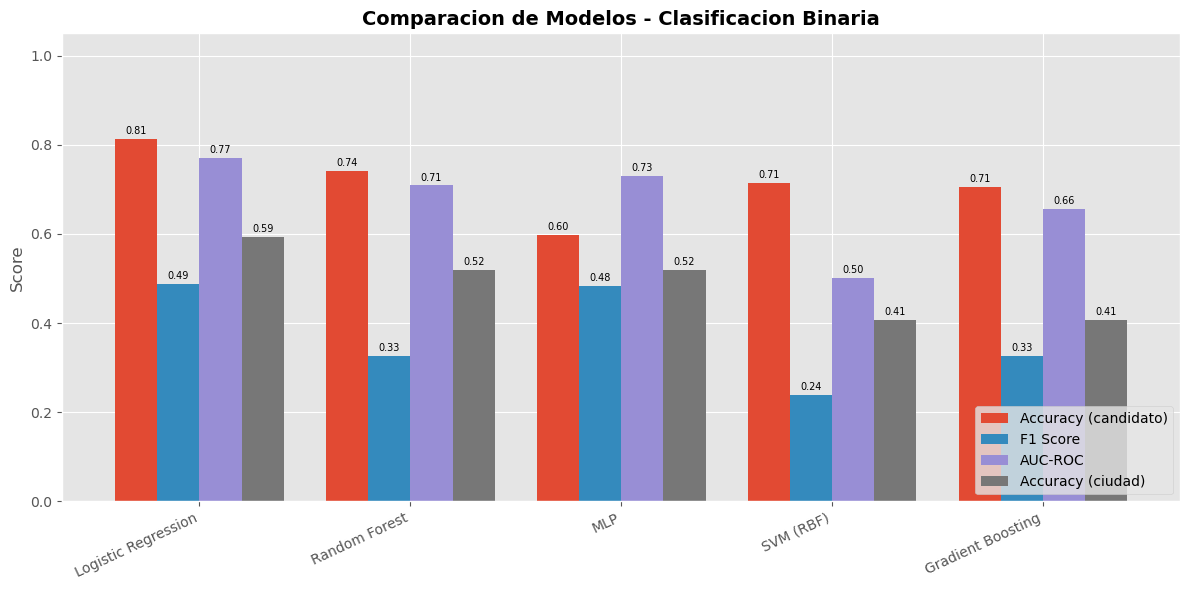

In [8]:
df_comp = pd.DataFrame({
    name: {
        'Accuracy (candidato)': res['Accuracy'],
        'F1 Score': res['F1'],
        'AUC-ROC': res['AUC'],
        'Accuracy (ciudad)': city_results[name]['pct'] / 100
    }
    for name, res in results.items()
}).T.sort_values('Accuracy (ciudad)', ascending=False)

print('=== TABLA COMPARATIVA FINAL ===')
print(df_comp.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
df_comp.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparacion de Modelos - Clasificacion Binaria', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(df_comp.index, rotation=25, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()


## 8. Analisis: Dominancia como Predictor

=== BASELINE: Mayor dominancia en engagement = ganador? ===
Aciertos: 19/27 (70.4%)

Comparacion:
  Baseline (dominancia):  70.4%
  Mejor modelo (Logistic Regression): 59.3%


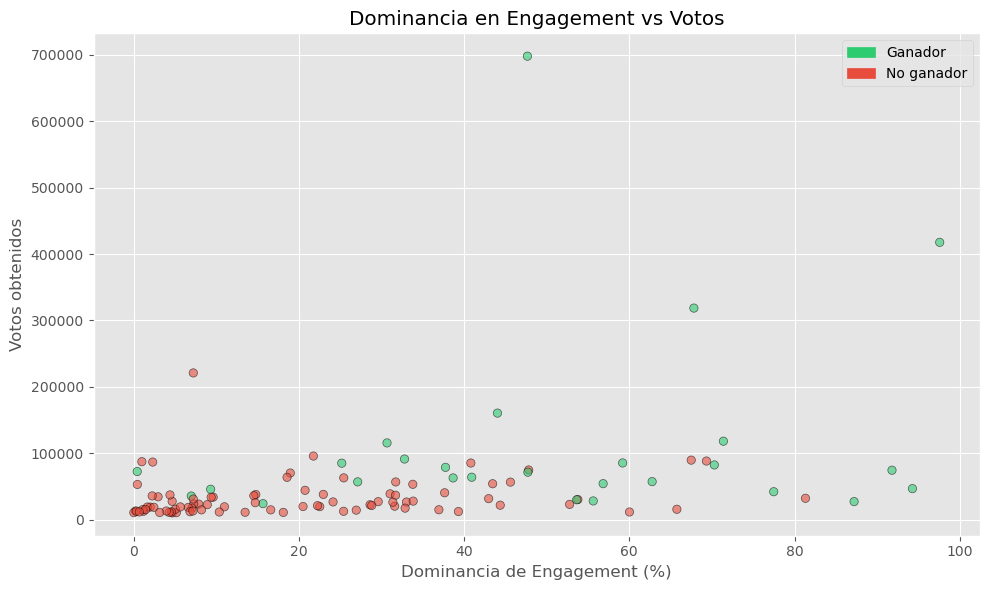

In [9]:
# Baseline: el candidato con mayor dominancia en engagement gana?
df_baseline = df[['Municipio', 'Candidato', 'dominancia_engagement', 'y']].copy()

aciertos_baseline = 0
total_baseline = 0

for ciudad, group in df_baseline.groupby('Municipio'):
    real = group[group['y'] == 1]
    if len(real) == 0:
        continue
    total_baseline += 1
    pred = group.loc[group['dominancia_engagement'].idxmax()]
    if pred['y'] == 1:
        aciertos_baseline += 1

print(f'=== BASELINE: Mayor dominancia en engagement = ganador? ===')
print(f'Aciertos: {aciertos_baseline}/{total_baseline} ({aciertos_baseline/total_baseline*100:.1f}%)')
print(f'\nComparacion:')
print(f'  Baseline (dominancia):  {aciertos_baseline/total_baseline*100:.1f}%')
print(f'  Mejor modelo ({best}): {city_results[best]["pct"]:.1f}%')

# Scatter
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if yi == 0 else '#2ecc71' for yi in df['y']]
ax.scatter(df['dominancia_engagement'], df['Votos'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Dominancia de Engagement (%)')
ax.set_ylabel('Votos obtenidos')
ax.set_title('Dominancia en Engagement vs Votos')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='Ganador'), 
                    Patch(color='#e74c3c', label='No ganador')])
plt.tight_layout()
plt.show()


## 9. Conclusiones

### Resultados
- La **clasificacion binaria** funciona mejor que la regresion para este problema con pocos datos.
- La **dominancia relativa** (% de interacciones del candidato vs su ciudad) es el feature mas poderoso.
- El modelo puede identificar correctamente al ganador en un porcentaje significativo de ciudades.

### Limitaciones
- Dataset pequeno (112 candidatos, 31 ciudades).
- Solo se usan interacciones en redes; factores como partido, incumbencia y campana offline no estan capturados.
- Los parametros de Weibull vienen calibrados de Costa Rica, no de Colombia.

### Implicaciones para la tesis
- Las interacciones en redes sociales **si tienen poder predictivo** sobre el resultado electoral.
- El engagement relativo (dominancia en la ciudad) importa mas que el absoluto.
